In [28]:
# ============================================================

# Libraries

# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import Rbf

from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
GridSearchCV,
KFold,
cross_validate
)

from sklearn.preprocessing import (
StandardScaler,
MinMaxScaler,
Normalizer,
PolynomialFeatures
)

from sklearn.metrics import (
make_scorer,
r2_score
)

from sklearn.ensemble import (
RandomForestRegressor,
ExtraTreesRegressor
)

import xgboost as xgb



from matplotlib.ticker import (
    FormatStrFormatter,
    MultipleLocator
)

import plotly.graph_objects as go


In [ ]:
# ============================================================

# Load original dataset

# ============================================================

DATA_FILE = Path("/home/ndong/Documents/balise_utile.csv")
DATA_FILE = Path("../data/output.csv")

balise_utile = pd.read_csv(DATA_FILE)

print(f"Dataset loaded: {len(balise_utile)} observations")
print(f"Number of variables: {balise_utile.shape[1]}")



Dataset loaded: 8766 observations
Number of variables: 18


In [31]:
balise_utile.columns

Index(['dossier', 'seance_id', 'dose_prescribed', 'debit', 'um_prevu',
       'charge', 'timestamp', 'um_del_1', 'duration', 'i_stripper',
       'i_chambre1', 'collimateur_area', 'um_prevu_del', 'um_del',
       'dose_delivered', 'duration_clean', 'i_chbr1', 'charge_par_dose'],
      dtype='object')

In [32]:
balise_utile = balise_utile[["debit", "dose_delivered", "um_del","dose_prescribed","charge"]]

In [34]:
balise_utile.to_csv("/home/ndong/proton-dose-calibration/data/input/input.csv", index=False)

In [3]:
# ============================================================

# Data cleaning: charge threshold

# ============================================================

MIN_CHARGE_PC = 5

# Calculate charge per delivered dose

balise_utile["charge_per_dose"] = (
balise_utile["charge"] / balise_utile["dose_delivered"]
)

# Select observations satisfying the physical criteria

mask_clean = (
(balise_utile["debit"] > 0)
& (balise_utile["charge_per_dose"] > 0)
& (balise_utile["charge"] >= MIN_CHARGE_PC)
)

# Select observations rejected because charge < 5 pC

mask_rejected = (
(balise_utile["debit"] > 0)
& (balise_utile["charge_per_dose"] > 0)
& (balise_utile["charge"] < MIN_CHARGE_PC)
)

df_clean = balise_utile.loc[mask_clean].copy()
df_rejected = balise_utile.loc[mask_rejected].copy()

print(f"Initial observations: {len(balise_utile)}")
print(f"Retained observations: {len(df_clean)}")
print(f"Rejected observations: {len(df_rejected)}")


Initial observations: 8766
Retained observations: 8719
Rejected observations: 47


In [4]:
df = df_clean.copy()

df["charge_per_dose"] = df["charge"] / df["dose_delivered"]
df["charge_per_mu"] = df["charge"] / df["um_del"]


df1 = df.loc[df["dose_prescribed"] == 13.0].copy()
df2 = df.loc[df["dose_prescribed"] == 5.625].copy()
df3 = df.loc[df["dose_prescribed"] == 2.17].copy()
df5 = df.loc[df["dose_prescribed"] == 6.5].copy()
df4 = df.loc[df["dose_prescribed"] == 4.33].copy()


def split_by_dossier(
    df,
    dossier_column="dossier",
    test_size=0.2,
    random_state=None
):
    """
    Split a DataFrame into two subsets according to unique dossier identifiers.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    dossier_column : str
        Name of the column containing the dossier identifiers.
    test_size : float
        Proportion of unique dossiers assigned to the test set.
    random_state : int or None
        Random seed for reproducibility.

    Returns
    -------
    df_train : pandas.DataFrame
        DataFrame containing the training dossiers.
    df_test : pandas.DataFrame
        DataFrame containing the test dossiers.
    """

    # Retrieve unique dossier identifiers
    unique_dossiers = df[dossier_column].unique()

    # Randomly select 20% of the dossiers without replacement
    test_dossiers = pd.Series(unique_dossiers).sample(
        frac=test_size,
        random_state=random_state
    )

    # Create the two DataFrames
    df_test = df[
        df[dossier_column].isin(test_dossiers)
    ]

    df_train = df[
        ~df[dossier_column].isin(test_dossiers)
    ]

    return df_train, df_test


df1_80, df1_20 = split_by_dossier(
    df1,
    dossier_column="dossier",
    test_size=0.2,
    random_state=4
)

df2_80, df2_20 = split_by_dossier(
    df2,
    dossier_column="dossier",
    test_size=0.2,
    random_state=4
)

df3_80, df3_20 = split_by_dossier(
    df3,
    dossier_column="dossier",
    test_size=0.2,
    random_state=6
)

df4_80, df4_20 = split_by_dossier(
    df4,
    dossier_column="dossier",
    test_size=0.2,
    random_state=50
)

df5_80, df5_20 = split_by_dossier(
    df5,
    dossier_column="dossier",
    test_size=0.2,
    random_state=6
)

# df_80, df_20 = split_by_dossier(
#     df,
#     dossier_column="dossier",
#     test_size=0.2,
#     random_state=6
# )


df_train = pd.concat(
    [df1_80, df2_80, df3_80, df4_80, df5_80],
    ignore_index=True
)

df_train = df_train.sample(
    frac=1,
    random_state=10
).reset_index(drop=True)


df_test = pd.concat(
    [df1_20, df2_20, df3_20, df4_20, df5_20],
    ignore_index=True
)

df_test = df_test.sample(
    frac=1,
    random_state=10
).reset_index(drop=True)


===== Power-law fit results =====
a = 0.31785 ± 0.00029
b = -1.27320 ± 0.00165
a = 0.31785 ± 0.00058 (95% CI)
b = -1.27320 ± 0.00324 (95% CI)
R² = 0.99108


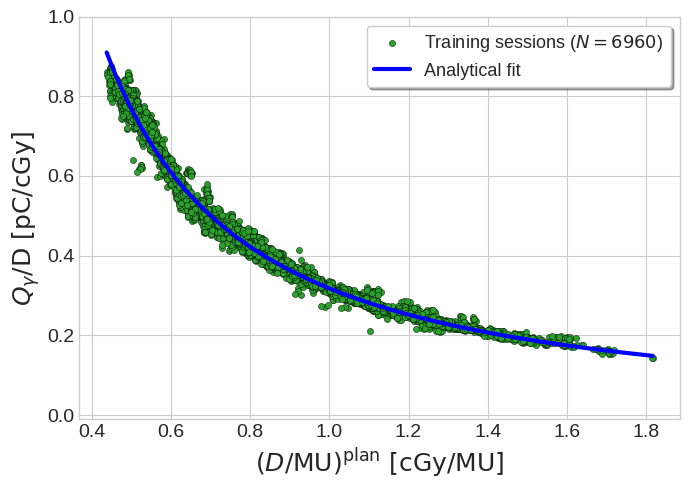

In [ ]:
# ============================================================
# Analytical model: inverse power-law
# ============================================================

def power_law(x, a, b):
    return a * x**b


# ============================================================
# Prepare data for fitting
# ============================================================

x_clean = df_train["debit"].values
y_clean = df_train["charge_per_dose"].values

# x_rejected = df_rejected["debit"].values
# y_rejected = df_rejected["charge_per_dose"].values


# ============================================================
# Fit
# ============================================================

params, covariance = curve_fit(
    power_law,
    x_clean,
    y_clean,
    maxfev=10000
)

a, b = params


# ============================================================
# Parameter uncertainties (1 sigma)
# ============================================================

sigma_a, sigma_b = np.sqrt(np.diag(covariance))


# ============================================================
# 95% confidence intervals
# ============================================================

ci95_a = 1.96 * sigma_a
ci95_b = 1.96 * sigma_b


# ============================================================
# Goodness of fit
# ============================================================

y_pred = power_law(
    x_clean,
    a,
    b
)

ss_res = np.sum(
    (y_clean - y_pred) ** 2
)

ss_tot = np.sum(
    (y_clean - np.mean(y_clean)) ** 2
)

r2 = 1 - ss_res / ss_tot


# ============================================================
# Results
# ============================================================

print("\n===== Power-law fit results =====")

print(f"a = {a:.5f} ± {sigma_a:.5f}")
print(f"b = {b:.5f} ± {sigma_b:.5f}")

print(f"a = {a:.5f} ± {ci95_a:.5f} (95% CI)")
print(f"b = {b:.5f} ± {ci95_b:.5f} (95% CI)")

print(f"R² = {r2:.5f}")


# ============================================================
# Model curve
# ============================================================

x_model = np.linspace(
    x_clean.min(),
    x_clean.max(),
    500
)

y_model = power_law(
    x_model,
    a,
    b
)


# ============================================================
# Figure
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(
    figsize=(7, 5)
)


# ------------------------------------------------------------
# Retained observations
# ------------------------------------------------------------

ax.scatter(
    x_clean,
    y_clean,
    s=20,
    alpha=1,
    color="tab:green",
    edgecolor="black",
    linewidth=0.3,
    label=rf"Training sessions ($N={len(x_clean)}$)"
)


# ------------------------------------------------------------
# Rejected observations
# ------------------------------------------------------------

# ax.scatter(
#     x_rejected,
#     y_rejected,
#     s=20,
#     color="red",
#     edgecolor="none",
#     label=rf"Data excluded from the fit ($Q_{{\gamma}} < 5$ pC, $N={len(x_rejected)}$)"
# )


# ------------------------------------------------------------
# Fitted model
# ------------------------------------------------------------

ax.plot(
    x_model,
    y_model,
    color="blue",
    linewidth=3,
    label="Analytical fit"
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_ylabel(
    r"$Q_{\gamma}/\mathrm{D}\ \mathrm{[pC/cGy]}$",
    fontsize=18
)

ax.set_xlabel(
    r"$(D/\mathrm{MU})^{\mathrm{plan}}\ [\mathrm{cGy}/\mathrm{MU}]$",
    fontsize=18
)


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.set_ylim(
    -0.01,
    1
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "../results/figures/power_law_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


===== Fit quality =====
R² analytical fit = 0.837393


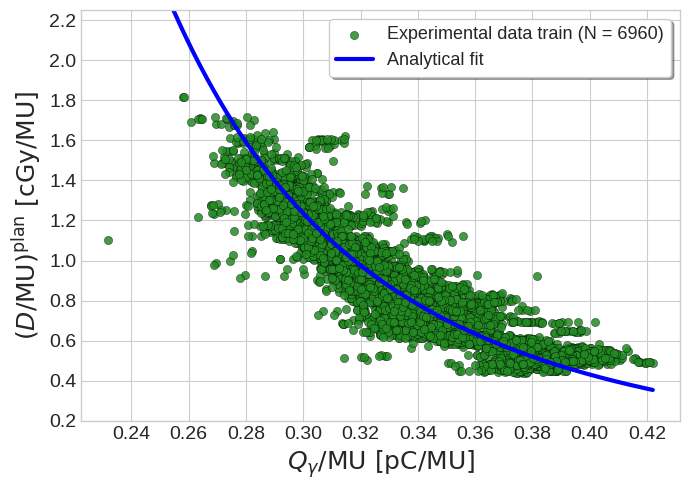

In [ ]:



# ============================================================
# Data
# ============================================================

x_data = (
    df_train["charge"] / df_train["um_del"]
).values

y_data = df_train["debit"].values


# ============================================================
# R² function
# ============================================================

def compute_r2(y_true, y_pred):
    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - ss_res / ss_tot


# ============================================================
# Analytical model
# ============================================================

a_analytic = a#0.3153522549253796
b_analytic = b#-1.2719957437571852

y_pred_analytic = (
    x_data / a_analytic
) ** (1 / (1 + b_analytic))

r2_analytic = compute_r2(
    y_data,
    y_pred_analytic
)


# ============================================================
# Power-law model
# ============================================================

# y = a * x^b

y_pred_power = (
    a * x_data ** b
)

r2_power = compute_r2(
    y_data,
    y_pred_power
)


# ============================================================
# Smooth curves
# ============================================================

x_mod = np.linspace(
    x_data.min(),
    x_data.max(),
    1000
)

y_mod_analytic = (
    x_mod / a_analytic
) ** (1 / (1 + b_analytic))

y_mod_power = (
    a * x_mod ** b
)


# ============================================================
# Results
# ============================================================

print("\n===== Fit quality =====")

print(
    f"R² analytical fit = {r2_analytic:.6f}"
)

#print(
#    f"R² power-law fit  = {r2_power:.6f}"
#)


# ============================================================
# Figure
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(
    figsize=(7, 5)
)


# ------------------------------------------------------------
# Experimental data
# ------------------------------------------------------------

ax.scatter(
    x_data,
    y_data,
    s=35,
    alpha=0.85,
    color="forestgreen",
    edgecolor="black",
    linewidth=0.3,
    label=f"Experimental data train (N = {len(x_data)})"
)


# ------------------------------------------------------------
# Analytical fit
# ------------------------------------------------------------

ax.plot(
    x_mod,
    y_mod_analytic,
    color="blue",
    linewidth=3,
    label="Analytical fit"
)


# ------------------------------------------------------------
# Power-law fit
# ------------------------------------------------------------

# ax.plot(
#     x_mod,
#     y_mod_power,
#     color="blue",
#     linewidth=3,
#     label=rf"Power-law fit ($R^2={r2_power:.4f}$)"
# )


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    r"$Q_{\gamma}/\mathrm{MU}\ \mathrm{[pC/MU]}$",
    fontsize=18
)

ax.set_ylabel(
    r"$(D/\mathrm{MU})^{\mathrm{plan}}\ [\mathrm{cGy}/\mathrm{MU}]$",
    fontsize=18
)


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.xaxis.set_major_locator(
    MultipleLocator(0.02)
)

ax.xaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax.yaxis.set_major_locator(
    MultipleLocator(0.2)
)

ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.set_ylim(
    0.2,
    2.25
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "../results/figures/inverse_power_law_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# RBF fit and 3D visualization on the training dataset
# ============================================================




# ============================================================
# Training data
# ============================================================

charge_train = df_train["charge"].values
mu_train = df_train["um_del"].values
debit_train = df_train["debit"].values


# ============================================================
# Fit RBF interpolator
# ============================================================

rbf = Rbf(
    charge_train,
    mu_train,
    debit_train,
    function="multiquadric",
    smooth=0.1
)

print("RBF interpolator fitted successfully.")


# ============================================================
# Create a grid over the training data range
# ============================================================

charge_grid = np.linspace(
    charge_train.min(),
    charge_train.max(),
    100
)

mu_grid = np.linspace(
    mu_train.min(),
    mu_train.max(),
    100
)

charge_mesh, mu_mesh = np.meshgrid(
    charge_grid,
    mu_grid
)


# ============================================================
# Evaluate the fitted RBF on the grid
# ============================================================

debit_mesh = rbf(
    charge_mesh,
    mu_mesh
)

# Enforce the physical constraint D/MU >= 0
debit_mesh = np.maximum(
    debit_mesh,
    0
)


# ============================================================
# 3D visualization
# ============================================================

fig = go.Figure()


# ------------------------------------------------------------
# RBF surface
# ------------------------------------------------------------

fig.add_trace(
    go.Surface(
        x=charge_mesh,
        y=mu_mesh,
        z=debit_mesh,
        colorscale="Viridis",
        opacity=0.85,
        showscale=True,

        colorbar=dict(
            title=dict(
                text="(D/MU)ᵖˡᵃⁿ [cGy/MU]",
                font=dict(size=22)
            ),
            tickfont=dict(size=16)
        ),

        name="RBF surface"
    )
)


# ------------------------------------------------------------
# Training data
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter3d(
        x=charge_train,
        y=mu_train,
        z=debit_train,
        mode="markers",
        marker=dict(
            size=2,
            color="black",
            opacity=0.35
        ),
        name=f"Training sessions (N={len(df_train)})"
    )
)


# ============================================================
# Axis labels and layout
# ============================================================

fig.update_layout(
    width=1200,
    height=900,


    scene=dict(

        xaxis=dict(
            title=dict(
                text="Qγ [pC]",
                font=dict(size=22)
            ),
            tickfont=dict(size=16)
        ),

        yaxis=dict(
            title=dict(
                text="MU",
                font=dict(size=22)
            ),
            tickfont=dict(size=16)
        ),

        zaxis=dict(
            title=dict(
                text="(D/MU)ᵖˡᵃⁿ [cGy/MU]",
                font=dict(size=22)
            ),
            tickfont=dict(size=16)
        )
    )
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "../results/figures/rbf_fit.png",
    dpi=300,
    bbox_inches="tight"
)

fig.show()

RBF interpolator fitted successfully.


In [8]:
# ============================================================
# Machine-learning configuration
# ============================================================

RANDOM_STATE = 42
POLY_DEGREE = 4
EPS = 1e-12


# ============================================================
# Target variable
# ============================================================

y = df_train["debit"].values


# ============================================================
# Selected configurations
# ============================================================
# Aligned with the evaluated feature / operation / model
# combinations.

selected_configs = [

    {
        "Features": r"$Q_{\gamma}$/MU, MU, $Q_{\gamma}$",
        "Variables": [
            "charge_per_mu",
            "um_del",
            "charge"
        ],
        "Operations": "Raw",
        "Model": "ET"
    },

    {
        "Features": r"$Q_{\gamma}$, MU",
        "Variables": [
            "charge",
            "um_del"
        ],
        "Operations": "Poly + Norm",
        "Model": "RF"
    },

    {
        "Features": r"$Q_{\gamma}$/MU, MU",
        "Variables": [
            "charge_per_mu",
            "um_del"
        ],
        "Operations": "Poly + Std",
        "Model": "RF"
    },

    {
        "Features": r"$Q_{\gamma}$/MU, $Q_{\gamma}$",
        "Variables": [
            "charge_per_mu",
            "charge"
        ],
        "Operations": "Raw",
        "Model": "ET"
    },

    {
        "Features": r"$Q_{\gamma}$/MU",
        "Variables": [
            "charge_per_mu"
        ],
        "Operations": "Raw",
        "Model": "XGB"
    },

    {
        "Features": r"$Q_{\gamma}$",
        "Variables": [
            "charge"
        ],
        "Operations": "Poly + Std",
        "Model": "XGB"
    },

    {
        "Features": "MU",
        "Variables": [
            "um_del"
        ],
        "Operations": "Poly + Norm",
        "Model": "XGB"
    }
]

In [9]:
# ============================================================
# Relative-error metrics
# ============================================================

def relative_errors(y_true, y_pred):
    return (
        100
        * (y_pred - y_true)
        / (y_true + EPS)
    )


def relative_mae(y_true, y_pred):
    return np.mean(
        np.abs(
            relative_errors(
                y_true,
                y_pred
            )
        )
    )


def relative_rmse(y_true, y_pred):
    return np.sqrt(
        np.mean(
            relative_errors(
                y_true,
                y_pred
            ) ** 2
        )
    )


def relative_std(y_true, y_pred):
    return np.std(
        relative_errors(
            y_true,
            y_pred
        )
    )

In [10]:
# ============================================================
# Utility functions for comparative clinical metrics
# ============================================================

def bootstrap_metrics(
    y_true,
    y_pred,
    n_boot=1000,
    seed=42
):
    """
    Compute bootstrap 95% confidence intervals for
    relative MAE, relative RMSE, and relative standard deviation.
    """

    rng = np.random.default_rng(
        seed
    )

    n = len(
        y_true
    )

    mae_boot = []
    rmse_boot = []
    std_boot = []

    for _ in range(n_boot):

        idx = rng.choice(
            n,
            size=n,
            replace=True
        )

        yt = y_true[idx]
        yp = y_pred[idx]

        err = (
            100
            * (yp - yt)
            / (yt + EPS)
        )

        mae_boot.append(
            np.mean(
                np.abs(err)
            )
        )

        rmse_boot.append(
            np.sqrt(
                np.mean(
                    err ** 2
                )
            )
        )

        std_boot.append(
            np.std(err)
        )

    return (
        np.percentile(
            mae_boot,
            [2.5, 97.5]
        ),
        np.percentile(
            rmse_boot,
            [2.5, 97.5]
        ),
        np.percentile(
            std_boot,
            [2.5, 97.5]
        )
    )


def build_summary_row(
    model,
    method,
    err,
    y_true,
    y_pred
):

    ci_mae, ci_rmse, ci_std = (
        bootstrap_metrics(
            y_true,
            y_pred
        )
    )

    return {
        "Model": model,
        "Method": method,
        "MAE (%)": np.mean(
            np.abs(err)
        ),
        "RMSE (%)": np.sqrt(
            np.mean(
                err ** 2
            )
        ),
        "STD (%)": np.std(err),
        "Median (%)": np.median(err),
        "Outside MAE ±3 (%)":
            100 * np.mean(
                np.abs(err) > 3
            ),
        "Outside MAE ±5 (%)":
            100 * np.mean(
                np.abs(err) > 5
            ),
        "Outside MAE ±10 (%)":
            100 * np.mean(
                np.abs(err) > 10
            ),
        "MAE 95% CI":
            f"[{ci_mae[0]:.2f}, "
            f"{ci_mae[1]:.2f}]",
        "RMSE 95% CI":
            f"[{ci_rmse[0]:.2f}, "
            f"{ci_rmse[1]:.2f}]",
        "STD 95% CI":
            f"[{ci_std[0]:.2f}, "
            f"{ci_std[1]:.2f}]"
    }

In [11]:
# ============================================================
# Scoring
# ============================================================

scoring = {
    "R2": "r2",
    "MAE_rel": make_scorer(
        relative_mae,
        greater_is_better=False
    ),
    "RMSE_rel": make_scorer(
        relative_rmse,
        greater_is_better=False
    ),
    "STD_rel": make_scorer(
        relative_std,
        greater_is_better=False
    )
}


# ============================================================
# Cross-validation
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [12]:
# ============================================================
# Transformations
# ============================================================

transformations = {

    "Raw": [],

    "StandardScaler": [
        ("std", StandardScaler())
    ],

    "MinMaxScaler": [
        ("minmax", MinMaxScaler())
    ],

    "Normalizer": [
        ("norm", Normalizer())
    ],

    "Poly": [
        (
            "poly",
            PolynomialFeatures(
                POLY_DEGREE,
                include_bias=False
            )
        )
    ],

    "Poly + Std": [
        (
            "poly",
            PolynomialFeatures(
                POLY_DEGREE,
                include_bias=False
            )
        ),
        (
            "std",
            StandardScaler()
        )
    ],

    "Poly + MinMax": [
        (
            "poly",
            PolynomialFeatures(
                POLY_DEGREE,
                include_bias=False
            )
        ),
        (
            "minmax",
            MinMaxScaler()
        )
    ],

    "Poly + Norm": [
        (
            "poly",
            PolynomialFeatures(
                POLY_DEGREE,
                include_bias=False
            )
        ),
        (
            "norm",
            Normalizer()
        )
    ]
}

In [13]:
# ============================================================
# Machine-learning models
# ============================================================

models = {

    "RF": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ET": ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGB": xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [14]:
# ============================================================
# Hyperparameter grids
# ============================================================

param_grids = {

    "RF": {
        "model__n_estimators": [
            100,
            200,
            500
        ],
        "model__max_depth": [
            None,
            5,
            10,
            20
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            5
        ]
    },

    "ET": {
        "model__n_estimators": [
            100,
            200,
            500
        ],
        "model__max_depth": [
            None,
            5,
            10,
            20
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            5
        ]
    },

    "XGB": {
        "model__n_estimators": [
            100,
            200,
            500
        ],
        "model__max_depth": [
            2,
            4,
            6
        ],
        "model__learning_rate": [
            0.01,
            0.05,
            0.1
        ],
        "model__subsample": [
            0.8,
            1.0
        ],
        "model__colsample_bytree": [
            0.8,
            1.0
        ]
    }
}

In [15]:
# ============================================================
# Grid search and cross-validation
# ============================================================

results = []
best_estimators = {}


for cfg in selected_configs:

    print(
        f"\n===== {cfg['Features']} ====="
    )

    X = df_train[
        cfg["Variables"]
    ]

    pipe = Pipeline(
        transformations[
            cfg["Operations"]
        ]
        + [
            (
                "model",
                models[
                    cfg["Model"]
                ]
            )
        ]
    )

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[
            cfg["Model"]
        ],
        scoring="r2",
        cv=cv,
        n_jobs=-1
    )

    search.fit(
        X,
        y
    )

    best_pipe = search.best_estimator_

    best_estimators[
        cfg["Features"]
    ] = {
        "pipeline": best_pipe,
        "variables": cfg["Variables"]
    }

    cv_results = cross_validate(
        best_pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append(
        {
            "Features": cfg["Features"],
            "Operations": cfg["Operations"],
            "Model": cfg["Model"],
            "Best_Params": search.best_params_,
            "CV_R2": np.mean(
                cv_results["test_R2"]
            ),
            "CV_R2_STD": np.std(
                cv_results["test_R2"]
            ),
            "MAE_percent": np.mean(
                -cv_results["test_MAE_rel"]
            ),
            "RMSE_percent": np.mean(
                -cv_results["test_RMSE_rel"]
            ),
            "STD_percent": np.mean(
                -cv_results["test_STD_rel"]
            )
        }
    )


===== $Q_{\gamma}$/MU, MU, $Q_{\gamma}$ =====

===== $Q_{\gamma}$, MU =====

===== $Q_{\gamma}$/MU, MU =====

===== $Q_{\gamma}$/MU, $Q_{\gamma}$ =====

===== $Q_{\gamma}$/MU =====

===== $Q_{\gamma}$ =====

===== MU =====


In [16]:
# ============================================================
# Final results after grid search
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "MAE_percent",
    ascending=True
)

print(
    "\n\n===== RESULTS AFTER GRID SEARCH "
    "(TRAIN, CV) ====="
)

display(
    results_df
)


# ============================================================
# Global model selection
# ============================================================

best_row = results_df.iloc[2]

best_features_name = best_row[
    "Features"
]

final_pipeline = best_estimators[
    best_features_name
]["pipeline"]

final_variables = best_estimators[
    best_features_name
]["variables"]

print(
    f"\nFinal selected model: "
    f"{best_features_name} | "
    f"{best_row['Operations']} | "
    f"{best_row['Model']}"
)



===== RESULTS AFTER GRID SEARCH (TRAIN, CV) =====


,Features,Operations,Model,Best_Params,CV_R2,CV_R2_STD,MAE_percent,RMSE_percent,STD_percent
0,"$Q_{\gamma}$/MU, MU, $Q_{\gamma}$",Raw,ET,"{'model__max_depth': 20, 'model__min_samples_l...",0.967935,0.006443,2.394277,6.426627,6.412314
2,"$Q_{\gamma}$/MU, MU",Poly + Std,RF,"{'model__max_depth': 20, 'model__min_samples_l...",0.963914,0.006299,2.469887,6.684950,6.669182
1,"$Q_{\gamma}$, MU",Poly + Norm,RF,"{'model__max_depth': 20, 'model__min_samples_l...",0.964063,0.006352,2.525612,6.688629,6.675224
3,"$Q_{\gamma}$/MU, $Q_{\gamma}$",Raw,ET,"{'model__max_depth': 20, 'model__min_samples_l...",0.965692,0.006167,2.610200,6.625969,6.609184
4,$Q_{\gamma}$/MU,Raw,XGB,"{'model__colsample_bytree': 0.8, 'model__learn...",0.872106,0.009423,8.650262,11.706236,11.614954
5,$Q_{\gamma}$,Poly + Std,XGB,"{'model__colsample_bytree': 0.8, 'model__learn...",0.511320,0.018779,18.341658,27.969889,27.346638
6,MU,Poly + Norm,XGB,"{'model__colsample_bytree': 1.0, 'model__learn...",0.411451,0.024564,19.465126,31.173895,30.309168



Final selected model: $Q_{\gamma}$, MU | Poly + Norm | RF


In [17]:
# ============================================================
# Final retraining on the complete training set
# ============================================================

X_train_final = df_train[
    final_variables
]

final_pipeline.fit(
    X_train_final,
    y
)

,steps,"[('poly', ...), ('norm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,4
,interaction_only,False
,include_bias,False
,order,'C'
,norm,'l2'
,copy,True
,n_estimators,200


In [18]:
# ============================================================
# Prepare the independent test set
# ============================================================

if (
    "charge_per_mu" in final_variables
    and "charge_per_mu" not in df_test.columns
):
    df_test = df_test.copy()

    df_test["charge_per_mu"] = (
        df_test["charge"]
        / (df_test["um_del"] + EPS)
    )

X_test_final = df_test[
    final_variables
]

In [19]:
# ============================================================
# Predictions on the independent test set
# ============================================================

y_pred_test = final_pipeline.predict(
    X_test_final
)

predictions_df = df_test.copy()


model_names = {
    "RF": "RandomForest",
    "ET": "ExtraTrees",
    "XGB": "XGBoost"
}


best_ml_name = model_names.get(
    best_row["Model"],
    best_row["Model"]
)


predictions_df[
    f"debit_predicted_{best_ml_name}"
] = y_pred_test


print(
    "\n===== PREDICTIONS ON INDEPENDENT TEST SET ====="
)

display(
    predictions_df.head()
)


===== PREDICTIONS ON INDEPENDENT TEST SET =====


,dossier,seance_id,dose_prescribed,debit,um_prevu,charge,timestamp,um_del_1,duration,i_stripper,...,collimateur_area,um_prevu_del,um_del,dose_delivered,duration_clean,i_chbr1,charge_par_dose,charge_per_dose,charge_per_mu,debit_predicted_RandomForest
0,23138,7002,13.0,0.527264,2466,966.9999,2023-07-11 11:37:01.457,"{0,0,0,0,0,0,0,0,3,10,18,26,34,42,50,57,65,73,...","{0,0,0,0,0,0,0.03,0.08,0.131,0.18,0.231,0.28,0...",404,...,57.491700,2466.0,2466.0,1300.234050,15.698,333.997015,0.743712,0.743712,0.392133,0.526721
1,21101,4507,13.0,0.663316,1960,680.3000,2021-05-18 11:58:12.309,"{0,0,0,0,0,0,0,0,4,13,22,31,40,50,59,68,77,86,...","{0,0,0,0,0,0,0.033,0.084,0.133,0.184,0.233,0.2...",404,...,198.994143,1960.0,1960.0,1300.099967,10.638,379.816239,0.523267,0.523267,0.347092,0.663717
2,18219,1809,13.0,0.506431,2568,105.3300,2018-12-20 09:39:53.143,"{0,25,67,109,152,194,235,267,267,267,267,267}","{0.205,0.465,0.725,0.986,1.255,1.516,1.776,2.0...",408,...,252.009595,267.0,267.0,135.217165,4.006,231.318182,0.778969,0.778969,0.394494,0.530111
3,23246,7511,13.0,0.547386,2374,942.9000,2023-12-21 14:02:58.880,"{0,0,0,0,0,0,0,0,1,8,16,24,31,39,46,54,62,69,7...","{0,0,0,0,0,0,0.019,0.068,0.118,0.169,0.219,0.2...",404,...,239.783755,2374.0,2375.0,1300.042719,15.431,326.196970,0.725284,0.725284,0.397011,0.547087
4,20131,3591,13.0,0.682987,1904,637.0000,2020-08-14 11:17:58.647,"{0,27,73,120,166,212,212,303,349,396,442,489,5...","{0.204,0.463,0.724,0.984,1.244,1.504,1.764,2.0...",404,...,227.588855,1904.0,1902.0,1299.042207,12.175,396.892857,0.490361,0.490361,0.334911,0.684788


In [20]:
# ============================================================
# Independent test-set metrics
# ============================================================

if "debit" in df_test.columns:

    y_test_true = (
        df_test["debit"].values
    )

    test_r2 = r2_score(
        y_test_true,
        y_pred_test
    )

    test_mae = relative_mae(
        y_test_true,
        y_pred_test
    )

    test_rmse = relative_rmse(
        y_test_true,
        y_pred_test
    )

    test_std = relative_std(
        y_test_true,
        y_pred_test
    )


    print(
        "\n===== PERFORMANCE ON "
        "INDEPENDENT TEST SET ====="
    )

    print(
        f"R²    = {test_r2:.4f}"
    )

    print(
        f"MAE%  = {test_mae:.2f}%"
    )

    print(
        f"RMSE% = {test_rmse:.2f}%"
    )

    print(
        f"STD%  = {test_std:.2f}%"
    )

else:

    print(
        "\nColumn 'debit' is not available "
        "in the test set. Metrics cannot be "
        "computed; only predictions are available."
    )


===== PERFORMANCE ON INDEPENDENT TEST SET =====
R²    = 0.9406
MAE%  = 3.56%
RMSE% = 9.01%
STD%  = 8.98%


In [21]:
# ============================================================
# Comparative analysis on the independent test set
# Best ML models + RBF + analytical model
# ============================================================



if "debit" in df_test.columns:

    relative_errors_dict = {}

    labels = []

    summary = []


    model_names = {
        "RF": "Random Forest",
        "ET": "Extra Trees",
        "XGB": "XGBoost"
    }


    # --------------------------------------------------------
    # Machine-learning models
    # --------------------------------------------------------

    for cfg in selected_configs:

        pipe = best_estimators[
            cfg["Features"]
        ]["pipeline"]

        variables = best_estimators[
            cfg["Features"]
        ]["variables"]


        X_test = df_test[
            variables
        ].copy()

        y_true = (
            df_test["debit"].values
        )


        mask = (
            np.isfinite(X_test).all(axis=1)
            & np.isfinite(y_true)
        )


        X_test = X_test.loc[
            mask
        ]

        y_true = y_true[
            mask
        ]


        y_pred = pipe.predict(
            X_test
        )


        err = (
            100
            * (y_pred - y_true)
            / (y_true + EPS)
        )


        relative_errors_dict[
            cfg["Features"]
        ] = err


        labels.append(
            f"{cfg['Features']}\n"
            f"{model_names.get(cfg['Model'], cfg['Model'])}\n"
            f"{cfg['Operations']}"
        )


        summary.append(
            build_summary_row(
                cfg["Features"],
                cfg["Model"],
                err,
                y_true,
                y_pred
            )
        )


    # --------------------------------------------------------
    # RBF interpolator
    # --------------------------------------------------------

    rbf = Rbf(
        df_train["charge"].values,
        df_train["um_del"].values,
        df_train["debit"].values,
        function="multiquadric",
        smooth=0.1
    )


    z_true = (
        df_test["debit"].values
    )


    z_pred = rbf(
        df_test["charge"].values,
        df_test["um_del"].values
    )


    predictions_df[
        "debit_predicted_RBF"
    ] = z_pred


    err = (
        100
        * (z_pred - z_true)
        / (z_true + EPS)
    )

    err = err[
        np.isfinite(err)
    ]


    relative_errors_dict[
        "RBF"
    ] = err


    labels.append(
        r"$Q_{\gamma}$, MU"
        "\n"
        "RBF Interpolator"
    )


    summary.append(
        build_summary_row(
            "RBF",
            "Interpolator",
            err,
            z_true,
            z_pred
        )
    )


    # --------------------------------------------------------
    # Analytical model
    # --------------------------------------------------------

    a_analytic = a
    b_analytic = b


    x = (
        df_test["charge_per_mu"].values
    )

    y_true = (
        df_test["debit"].values
    )


    y_pred = (
        x / a_analytic
    ) ** (
        1 / (1 + b_analytic)
    )


    predictions_df[
        "debit_predicted_Analytical"
    ] = y_pred


    err = (
        100
        * (y_pred - y_true)
        / (y_true + EPS)
    )

    err = err[
        np.isfinite(err)
    ]


    relative_errors_dict[
        "Analytical"
    ] = err


    labels.append(
        r"$Q_{\gamma}$/MU"
        "\n"
        "Analytical Model"
    )


    summary.append(
        build_summary_row(
            "Analytical",
            "Analytical",
            err,
            y_true,
            y_pred
        )
    )

In [22]:
# ============================================================
# Summary tables and export
# ============================================================

summary_df = pd.DataFrame(
    summary
)


print(
    "\n===== RELATIVE ERROR SUMMARY ====="
)

display(
    summary_df
)


# Save summary and predictions
summary_df.to_csv(
    "Summary_models.csv",
    index=False
)

predictions_df.to_csv(
    "Predictions_models.csv",
    index=False
)


===== RELATIVE ERROR SUMMARY =====


,Model,Method,MAE (%),RMSE (%),STD (%),Median (%),Outside MAE ±3 (%),Outside MAE ±5 (%),Outside MAE ±10 (%),MAE 95% CI,RMSE 95% CI,STD 95% CI
0,"$Q_{\gamma}$/MU, MU, $Q_{\gamma}$",ET,3.573157,8.861694,8.835071,-0.014303,25.810119,19.727118,12.336555,"[3.21, 3.96]","[7.40, 10.55]","[7.37, 10.50]"
1,"$Q_{\gamma}$, MU",RF,3.556151,9.005009,8.983441,-0.028593,25.071063,19.613417,11.881751,"[3.18, 3.95]","[7.42, 10.69]","[7.41, 10.65]"
2,"$Q_{\gamma}$/MU, MU",RF,3.626165,9.085804,9.052365,-0.008557,25.753269,19.840819,12.279704,"[3.25, 4.02]","[7.62, 10.75]","[7.59, 10.70]"
3,"$Q_{\gamma}$/MU, $Q_{\gamma}$",ET,3.587636,8.702053,8.666341,0.006849,26.492325,20.011370,12.279704,"[3.24, 3.96]","[7.21, 10.39]","[7.17, 10.33]"
4,$Q_{\gamma}$/MU,XGB,9.312882,13.657231,13.397833,2.525335,78.681069,61.796475,33.712337,"[8.85, 9.82]","[12.23, 15.25]","[12.00, 14.89]"
5,$Q_{\gamma}$,XGB,20.649399,32.364414,31.084792,0.351182,69.982945,62.592382,53.155202,"[19.55, 21.91]","[30.51, 34.31]","[29.42, 32.83]"
6,MU,XGB,22.313866,36.143848,34.520703,0.211455,59.465605,54.803866,47.868107,"[21.08, 23.80]","[34.32, 38.20]","[32.94, 36.27]"
7,RBF,Interpolator,3.840293,9.125662,9.115908,-0.017213,27.117681,20.068221,13.132462,"[3.47, 4.24]","[7.76, 10.78]","[7.75, 10.76]"
8,Analytical,Analytical,10.318622,14.951768,14.826714,0.971998,79.192723,65.434906,41.273451,"[9.84, 10.82]","[13.48, 16.56]","[13.37, 16.37]"


/tmp/ipykernel_2880011/3508859146.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



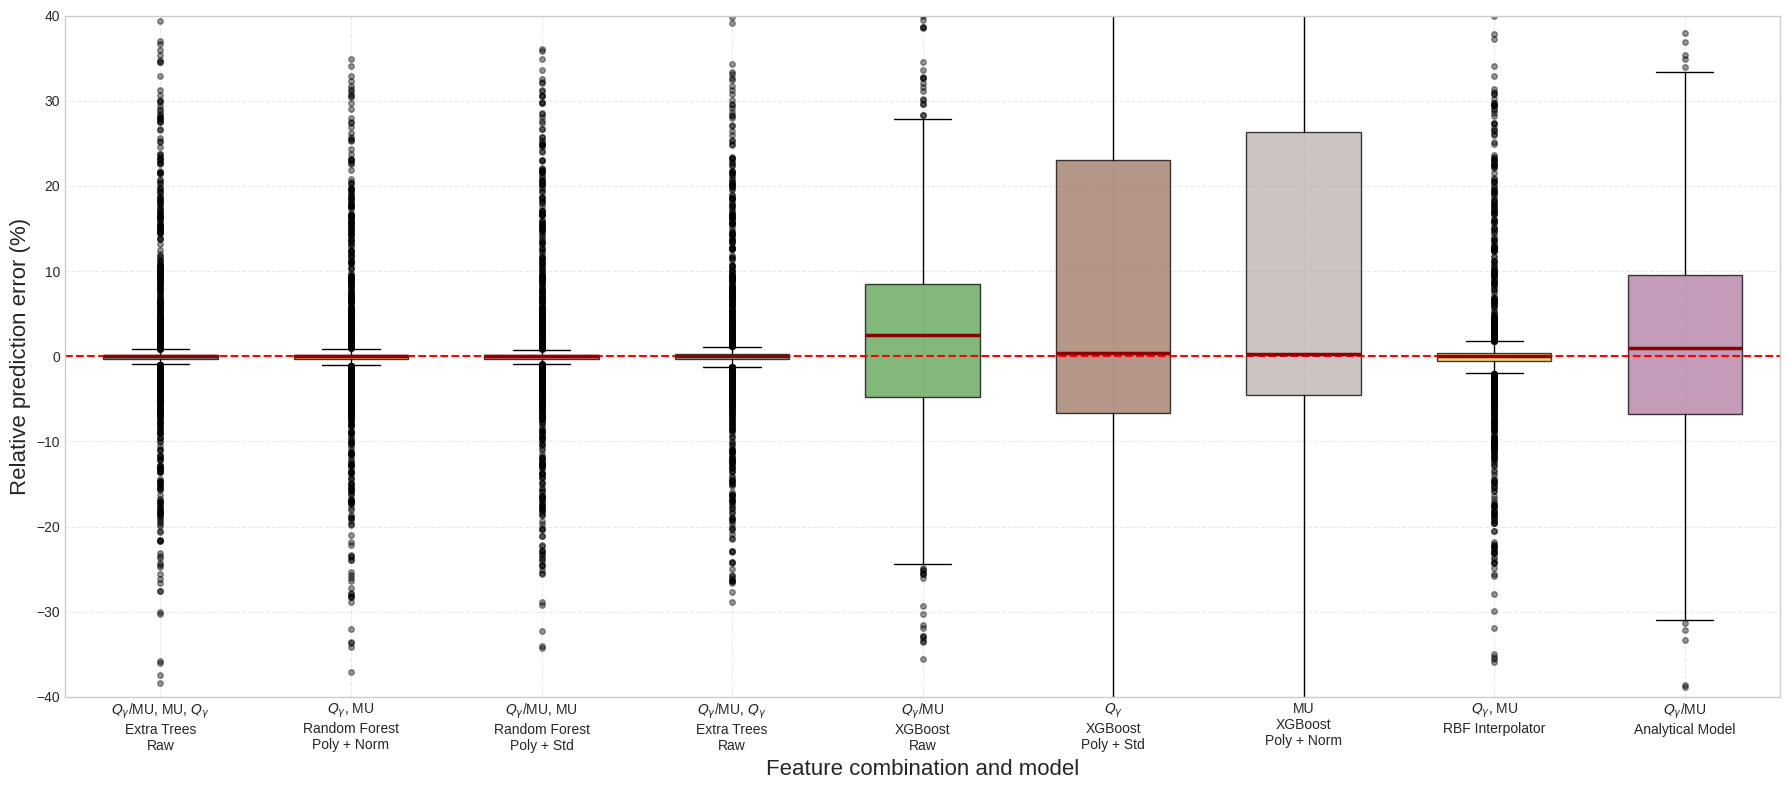

In [ ]:
# ============================================================
# Relative-error boxplot
# ============================================================

data = [
    relative_errors_dict[key]
    for key in relative_errors_dict
]


colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#9C755F",
    "#BAB0AC",
    "#EDC948",
    "#B07AA1"
]


fig, ax = plt.subplots(
    figsize=(18, 8)
)


bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    widths=0.6,
    showfliers=True
)


for patch, color in zip(
    bp["boxes"],
    colors
):
    patch.set_facecolor(
        color
    )

    patch.set_alpha(
        0.75
    )

    patch.set_edgecolor(
        "black"
    )


for median in bp["medians"]:

    median.set(
        color="darkred",
        linewidth=2.5
    )


for flier in bp["fliers"]:

    flier.set(
        marker="o",
        markersize=4,
        markerfacecolor="black",
        markeredgecolor="black",
        alpha=0.4
    )


ax.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)


ax.set_ylabel(
    "Relative prediction error (%)",
    fontsize=16
)

ax.set_xlabel(
    "Feature combination and model",
    fontsize=16
)


ax.set_ylim(
    -40,
    40
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)


plt.tight_layout()


plt.savefig(
    "../results/figures/box.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()